In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from meteor import MeteorInterface

FASTMIP Phase 1: \
METEOR emulation of annual tas and pr timeseries for all ESMs and 5 SSP scenarios. \
10 ensemble members, both with native METEOR noise and scaled to FAIR GSAT 50th percentile timeseries.

In [2]:
# FASTMIP Phase 1 output to generate:
# Up to 2100
# 2.5x2.5 degree common grid
# 10 member ensemble for each ESM and scenario
# Annual mean tas and pr (gridded)
# Both METEOR raw output and scaled to provided GSAT timeseries

ESMs = ['ACCESS-ESM1-5']#, 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5', 'EC-Earth3', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-LR', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp119']#, 'ssp126', 'ssp245', 'ssp370', 'ssp585']
FAIRpercentiles = ['5', '10', '50', '90', '95']
start_year = 2020
end_year = 2100
n_members = 10
output_dir = '../data/FASTMIP_phase1/METEOR_emulations/'
scaling_dir = '../data/FASTMIP_phase1/FAIR_GSAT/'

def format_FAIRssp(scenario):
    return f"SSP{scenario[3]}-{scenario[4:]}"

In [3]:
# Create emulators for list of ESMs (uses cached models if available)
for esm in ESMs:
    print(f"Creating emulator for {esm}...")
    emulator = MeteorInterface(
        model=esm,
        variables=['tas', 'pr'],
        cache_dir='../cache'
    )
    print(f"Emulator created for {emulator.model} with variables: {emulator.variables}")
    
    print(f"Training emulator for {emulator.model}...")
    emulator.train(verbose=True)

    for scenario in scenarios:
        print(f"Emulating scenario {scenario}...")

        # Emulate gridded outputs for each scenario and save:
        ensemble_gridded = emulator.generate_ensemble_outputs(
            scenario=scenario,
            start_year=start_year,
            end_year=end_year,
            n_realizations=n_members,
            timeseries=['global'], 
            gridded={
                'annual': list(range(start_year, end_year + 1)),  # Annual mean grids for all years 
                #'monthly': list(range(start_year, end_year + 1)),  # only annual currently.
            },
            save_to=f"{output_dir}METEOR_{esm}_{scenario}.nc"
        )

        # Scale output to FAIR GSAT:
        # (Could also loop through percentiles here, for now only using 50th)
        for percentile in ['50']: #FAIRpercentiles:    
            scaling_ts = xr.open_dataset(f"{scaling_dir}GSAT_SSPmarker_{format_FAIRssp(scenario)}.nc")['tas'].sel(percentile=percentile, SCM='FaIRv1.6.2', time=slice(start_year, end_year)).rename({'time': 'year'})
            #scaling_ts['year'] = pd.to_datetime(scaling_ts['year'].values.astype(str), format='%Y')

            ensemble_scaled = emulator.generate_ensemble_outputs(
                scenario=scenario,
                start_year=start_year,
                end_year=end_year,
                n_realizations=n_members,
                timeseries=['global'], 
                gridded={
                    'annual': list(range(start_year, end_year + 1)),  # Annual mean grids for all years
                    #'monthly': list(range(start_year, end_year + 1)),  # only annual currently.
                },
                temp_scaling_ts=scaling_ts,
                save_to=f"{output_dir}METEOR_{esm}_{scenario}_scaledtoFAIR_{percentile}percentile.nc"
            )   
        

Creating emulator for ACCESS-ESM1-5...
Emulator created for ACCESS-ESM1-5 with variables: ['tas', 'pr']
Training emulator for ACCESS-ESM1-5...
Training METEOR emulator for ACCESS-ESM1-5
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Model name mismatch: expected 'cmip6-ACCESS-ESM1-5-aer', found 'cmip6-ACCESS-ESM1-5-aer-tas'
🔧 Preparing pattern scaling training data for ACCESS-ESM1-5...
   ✅ Training data prepared for experiments:  ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
📦 Loading cached pattern scaling model from ../cache/pattern_scaling/cmip6-ACCESS-ESM1-5-aer-tas_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../cache/pattern_scaling/cmip6-ACCESS-ESM1-5-aer-tas_pattern_scaling.pkl
   → Training noise model...
Model loaded from ../cache/noise_models/ACCESS-ESM1-5

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
   → Gridded outputs...
      → Computing pattern scaling for tas, ssp119...
 Ts scaleing before calculating annual pred <xarray.DataArray 'year' (year: 81)> Size: 648B
array([2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031,
       2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043,
       2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055,
       2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067,
       2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079,
       2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091,
       2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100])
Coordinates:
  * year        (year) int64 648B 2020 2021 2022 2023 ..

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Generating 10 gridded realizations
      → Extracting annual means for 81 years
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for pr...
      → Using 2020 baseline for PR instead of piControl
      → Generating 10 stochastic PC realizations...
      • global
   → Gridded outputs...
      → Computing pattern scaling for pr, ssp119...
 Ts scaleing before calculating annual pred <xarray.DataArray 'year' (year: 81)> Size: 648B
array([2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031,
       2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043,
       2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055,
       2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067,
       2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079,
       2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091,
       2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100])
Coordinates:
  * year        (year) int64 648B 2020 2021 2022 2023 ... 2097 20

/home/mauracd/METEOR/src/meteor/meteor_interface.py:934: RuntimeWarning: invalid value encountered in divide
  temperature_input_anomaly.values / annual_temp_prediction_gm_anomaly.values,


      → Generating 10 gridded realizations
      → Extracting annual means for 81 years
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12
145 192 12

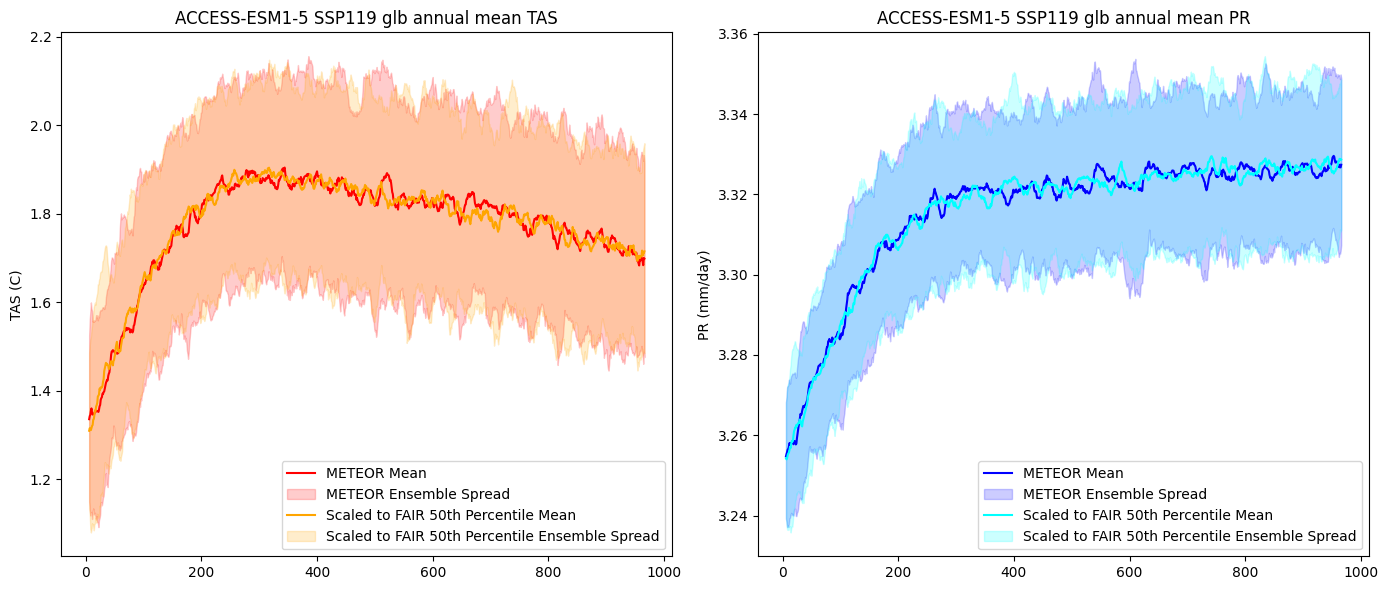

In [20]:
# plot global mean tas and pr

model = 'ACCESS-ESM1-5'
scenario = 'ssp119'
percentile = '50'
unscaled = xr.open_dataset(f"{output_dir}METEOR_{model}_{scenario}.nc")
scaled = xr.open_dataset(f"{output_dir}METEOR_{model}_{scenario}_scaledtoFAIR_{percentile}percentile.nc")

def plot_ens_spread(ax, data, variable, label, units, color):
    mean = data[f'{variable}_global'].mean(dim='realization').rolling(month=12, center=True).mean()
    max = data[f'{variable}_global'].max(dim='realization').rolling(month=12, center=True).mean()
    min = data[f'{variable}_global'].min(dim='realization').rolling(month=12, center=True).mean()

    if variable == 'pr':
        mean = mean * 86400  # convert from m/s to mm/day
        max = max * 86400
        min = min * 86400
    
    ax.plot(data['month'], mean, label=label+ ' Mean', color=color)
    ax.fill_between(data['month'], min, max, alpha=0.2, label=label+ ' Ensemble Spread', color=color)
    ax.set_ylabel(f'{variable.upper()} ({units})')
    ax.legend()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plot_ens_spread(ax[0], unscaled, 'tas', f'METEOR', 'C', 'red')
plot_ens_spread(ax[0], scaled, 'tas', f'Scaled to FAIR {percentile}th Percentile', 'C', 'orange')
ax[0].set_title(model + ' ' + scenario.upper() + ' glb annual mean TAS')
plot_ens_spread(ax[1], unscaled, 'pr', f'METEOR', 'mm/day', 'blue')
plot_ens_spread(ax[1], scaled, 'pr', f'Scaled to FAIR {percentile}th Percentile', 'mm/day', 'cyan')
ax[1].set_title(model + ' ' + scenario.upper() + ' glb annual mean PR')
plt.tight_layout()
plt.show()
